# Repeat Purchase Prediction — *Everything & Then Some*
**Machine Learning Homework 2026**

**Goal.** For every purchase, predict `repeat_purchase_90d`: whether the customer buys again within the next 90 days (binary classification).

**Notebook structure** (matches the grading items):

| Section | Content |
|---|---|
| 0 | Setup |
| 1 | Import and explore the data (`train.csv`, `clientes.csv`) |
| 2 | Clean and pre-process (anomalies, missing values, categorical variables, customer-table integration, feature engineering, scaling) |
| 3 | Feature selection |
| 4 | Model building, assessment and predictions for `test.csv` |

**Reproducibility rule.** `clean()` and `add_features()` are *stateless*: each row is transformed using only its own values. They are applied the same way to train and test. Everything that learns from data (imputation, scaling, encoding, feature selection, models) is fitted **on training data only**. The test set is only ever passed to `.predict`.

## 0. Setup

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
DATA = Path("data")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
FIG = OUT / "figures"; FIG.mkdir(exist_ok=True)
TARGET = "repeat_purchase_90d"
np.random.seed(RANDOM_STATE)

## 1. Import and explore the data
### 1.1 Load the three tables

In [2]:
train_raw = pd.read_csv(DATA / "train.csv")
test_raw = pd.read_csv(DATA / "test.csv")
clients_raw = pd.read_csv(DATA / "clientes.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")

for name, df in [("train", train_raw), ("test", test_raw), ("clientes", clients_raw), ("sample_submission", sample_sub)]:
    print(f"{name:18s} {df.shape[0]:>6,} rows x {df.shape[1]:>3} columns")
print("\nColumns only in train:", sorted(set(train_raw.columns) - set(test_raw.columns)))
train_raw.head()

train               6,534 rows x  39 columns
test                  986 rows x  38 columns
clientes            1,143 rows x  13 columns
sample_submission     986 rows x   2 columns

Columns only in train: ['repeat_purchase_90d']


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,repeat_purchase_90d,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
0,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,1,79.0,126.0,2.0,858.30,429.150000,112.656252,349.49,508.81,47.000000,NaN,0.0,0.00,1.0,349.49,2.0,858.30,2.0,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660448
1,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,1,244.0,616.0,5.0,6722.83,1344.566000,1683.795178,84.38,4222.15,93.000000,117.657696,0.0,0.00,0.0,0.00,0.0,0.00,4.0,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.924510
2,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,1,9.0,610.0,90.0,17590.08,195.445333,190.389932,4.54,1002.15,6.752809,6.384073,2.0,111.27,9.0,1928.55,28.0,5290.25,49.0,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.258730
3,856.83,696.61,696.61,160.22,0.0,0.0,0.00,408.167275,9.0,1.0,0,97.0,97.0,1.0,270.33,270.330000,NaN,270.33,270.33,NaN,NaN,0.0,0.00,0.0,0.00,1.0,270.33,1.0,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,10000003,1.448402
4,1616.10,1488.85,1313.90,302.20,0.0,0.0,174.95,485.401864,33.0,1.0,1,85.0,1575.0,25.0,12803.02,512.120800,406.696963,22.58,1736.74,62.083333,66.246520,0.0,0.00,2.0,184.13,4.0,2062.50,4.0,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,10000004,-1.058890


**Variables in `train.csv`** (one row = one purchase):

| Group | Columns | Meaning |
|---|---|---|
| Current order (invoice, Portuguese names) | `Total a Pagar` (amount due), `Total Bruto` (gross), `Total Liquido` (net), `Total Imp_` (tax), `Total Portes` (shipping), `Total Desc_ Global`/`Linha` (global/line discounts), `Custo` (cost), `N_ Detalhes` (number of lines), `invoice_count_current_purchase` | Value and content of the current purchase |
| Customer history (before this purchase) | `days_since_previous_purchase`, `customer_tenure_days`, `prior_*` (count, total, mean/std/min/max value, mean/std gap between purchases) | Recency, frequency and monetary (RFM) behaviour |
| Rolling windows | `purchase_count_{30,90,180,365}d`, `spend_{30,90,180,365}d` | Recent activity |
| Categorical context | `payment_type`, `salesperson`, `commercial_zone`, `transport_method`, `warehouse`, `document_series` | Anonymised operational labels |
| Identifiers / other | `customer_id`, `ID`, `purchase_date`, `random_noise` | Keys, date, and a pure-noise column |
| Target | `repeat_purchase_90d` | 1 if the customer buys again within 90 days |

In [3]:
info = pd.DataFrame({
    "dtype": train_raw.dtypes.astype(str),
    "n_missing": train_raw.isna().sum(),
    "pct_missing": (train_raw.isna().mean() * 100).round(2),
    "n_unique": train_raw.nunique(),
})
info

,dtype,n_missing,pct_missing,n_unique
Total a Pagar,float64,65,0.99,6122
Total Bruto,float64,65,0.99,6038
Total Liquido,float64,65,0.99,6093
Total Imp_,float64,65,0.99,5407
Total Portes,float64,65,0.99,215
Total Desc_ Global,float64,65,0.99,109
Total Desc_ Linha,float64,65,0.99,3520
Custo,float64,65,0.99,5740
N_ Detalhes,float64,65,0.99,171
invoice_count_current_purchase,float64,65,0.99,5


In [4]:
train_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Total a Pagar,6469.0,925.56,1335.00,0.93,188.92,476.74,1087.67,2.229721e+04
Total Bruto,6469.0,886.15,1327.64,0.83,175.74,445.74,1036.70,2.157828e+04
Total Liquido,6469.0,773.34,1136.36,0.76,154.38,389.91,903.37,1.812781e+04
Total Imp_,6469.0,152.22,225.26,0.00,29.93,79.74,184.84,4.169400e+03
Total Portes,6469.0,1.15,5.84,0.00,0.00,0.00,0.00,1.810600e+02
Total Desc_ Global,6469.0,0.35,5.12,0.00,0.00,0.00,0.00,2.184900e+02
Total Desc_ Linha,6469.0,112.47,289.99,0.00,0.00,13.13,92.28,4.103440e+03
Custo,6469.0,328.17,519.51,0.00,49.05,152.54,396.06,7.427400e+03
N_ Detalhes,6469.0,21.52,27.71,1.00,4.00,11.00,29.00,4.230000e+02
invoice_count_current_purchase,6469.0,1.07,0.31,1.00,1.00,1.00,1.00,5.000000e+00


### 1.2 Target variable

                        n   pct
repeat_purchase_90d            
0                    2880  44.1
1                    3654  55.9


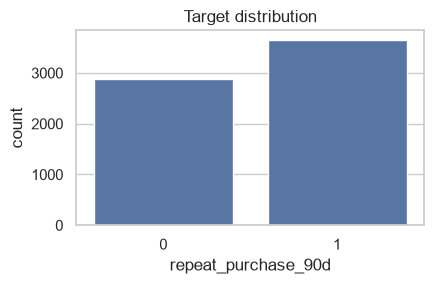

In [5]:
counts = train_raw[TARGET].value_counts().sort_index()
print(counts.to_frame("n").assign(pct=(counts / counts.sum() * 100).round(1)))
fig, ax = plt.subplots(figsize=(4.5, 3))
sns.countplot(x=TARGET, data=train_raw, ax=ax)
ax.set_title("Target distribution"); plt.tight_layout(); plt.show()

**Insight.** The classes are only mildly imbalanced: about 56% of purchases are followed by another purchase within 90 days. A model that always predicts "1" gets 56% accuracy, so accuracy alone says little. That is why we use threshold-independent ranking metrics (ROC-AUC, PR-AUC) together with balanced metrics (balanced accuracy, macro-F1).

### 1.3 Data quality: empty rows, duplicates, sentinels, impossible values

In [6]:
feature_cols_raw = [c for c in train_raw.columns if c not in ["ID", "customer_id", TARGET]]
empty_rows = train_raw[feature_cols_raw].isna().all(axis=1)
print(f"Rows with ALL features missing (only ID/customer/target present): {empty_rows.sum()}")
print(f"Duplicate rows (ignoring ID): {train_raw.drop(columns='ID').duplicated().sum()} "
      f"-> all of them are among the empty rows: {train_raw[~empty_rows].drop(columns='ID').duplicated().sum() == 0}")

num = train_raw.select_dtypes("number").drop(columns=["ID", "customer_id", "random_noise", TARGET])
print("\nValues >= 1e9 (sentinel codes):", (num >= 1e9).sum()[lambda s: s > 0].to_dict())
print("Negative values in non-negative quantities:", (num < 0).sum()[lambda s: s > 0].to_dict())

t = train_raw[~empty_rows]
checks = {
    "spend_180d > spend_365d": (t.spend_180d > t.spend_365d + 1e-6).sum(),
    "spend_365d > prior_total_spend": (t.spend_365d > t.prior_total_spend + 1e-6).sum(),
    "prior_max_purchase_value > prior_total_spend": (t.prior_max_purchase_value > t.prior_total_spend + 1e-6).sum(),
    "prior_min > prior_max": (t.prior_min_purchase_value > t.prior_max_purchase_value).sum(),
    "days_since_previous > tenure": (t.days_since_previous_purchase > t.customer_tenure_days).sum(),
    "Bruto != Liquido + discounts": ((t["Total Bruto"] - t["Total Liquido"] - t["Total Desc_ Linha"] - t["Total Desc_ Global"]).abs() > 0.01).sum(),
    "prior_mean != prior_total / prior_count": (~np.isclose(t.prior_total_spend / t.prior_purchase_count.replace(0, np.nan),
                                                           t.prior_mean_purchase_value) & (t.prior_purchase_count > 0)).sum(),
}
pd.Series(checks, name="n_violations").to_frame()

Rows with ALL features missing (only ID/customer/target present): 65
Duplicate rows (ignoring ID): 10 -> all of them are among the empty rows: True

Values >= 1e9 (sentinel codes): {'prior_mean_purchase_value': 16, 'spend_365d': 15}
Negative values in non-negative quantities: {'days_since_previous_purchase': 16, 'prior_mean_purchase_value': 16, 'prior_mean_gap_days': 16, 'spend_365d': 15}


,n_violations
spend_180d > spend_365d,15
spend_365d > prior_total_spend,54
prior_max_purchase_value > prior_total_spend,45
prior_min > prior_max,0
days_since_previous > tenure,0
Bruto != Liquido + discounts,0
prior_mean != prior_total / prior_count,272


**Insights.**
- **65 rows are empty**: every feature is missing and only `ID`, `customer_id` and the target are present. All 10 duplicate rows are among them. These rows carry no information and will be dropped from training.
- **Sentinel codes.** `1,000,000,000` appears in `prior_mean_purchase_value` and `spend_365d` (also in test). It is a "missing/error" code, not a real amount.
- **Impossible values.** Negative recency (`-4` days), negative mean spend, and negative `spend_365d`. A 365-day spend larger than the customer's *total* prior spend, and a maximum purchase larger than the total spend, are also inconsistent.
- **Useful accounting identities hold.** `Bruto = Liquido + discounts` always holds, and `prior_mean = prior_total / prior_count` holds for about 95% of rows. The identities let us **recompute** some corrupted values instead of discarding them.

### 1.4 Missing values and their structure

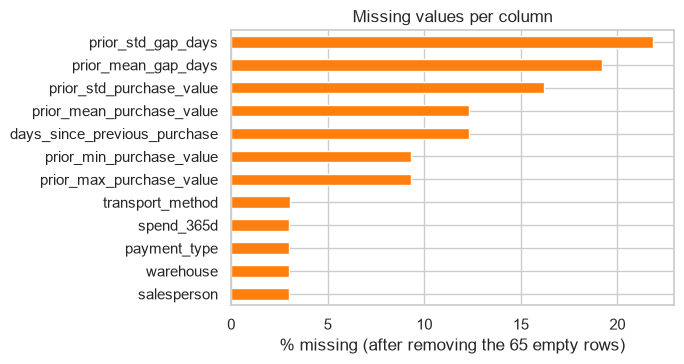

First purchases (prior_purchase_count == 0): 603
  of which days_since_previous_purchase missing: 100%
Missing days_since_previous_purchase with prior purchases > 0: 193

Co-occurrence of missing operational categoricals:
           0    1   2
n_rows  5720  718  31

Target rate when operational fields are missing vs present:
payment_type
present    0.560
missing    0.564
Name: repeat_purchase_90d, dtype: float64


In [7]:
miss = train_raw[~empty_rows].isna().mean().mul(100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.8))
miss.plot.barh(ax=ax, color="tab:orange"); ax.invert_yaxis()
ax.set_xlabel("% missing (after removing the 65 empty rows)"); ax.set_title("Missing values per column")
plt.tight_layout(); plt.show()

first = t.prior_purchase_count == 0
print(f"First purchases (prior_purchase_count == 0): {first.sum()}")
print(f"  of which days_since_previous_purchase missing: {t.loc[first, 'days_since_previous_purchase'].isna().mean():.0%}")
print(f"Missing days_since_previous_purchase with prior purchases > 0: {(t.days_since_previous_purchase.isna() & ~first).sum()}")
ops = ["payment_type", "salesperson", "transport_method", "warehouse"]
print("\nCo-occurrence of missing operational categoricals:")
print(t[ops].isna().sum(axis=1).value_counts().sort_index().rename("n_rows").to_frame().T)
print("\nTarget rate when operational fields are missing vs present:")
print(t.groupby(t.payment_type.isna())[TARGET].mean().rename({False: "present", True: "missing"}).round(3))

**Insights.**
- Most missing values are **structural**. On a customer's first purchase there is no previous purchase, so recency, prior mean/std and gaps cannot exist. The `prior_std_*` fields need at least 2 prior purchases. We encode this with an explicit `is_first_purchase` flag plus missing-value indicators. We do not drop these rows (603 first purchases).
- Operational categoricals (`payment_type`, `salesperson`, `transport_method`, `warehouse`) are missing *together* in about 200 rows, so this is a data-extraction problem. We treat "Missing" as its own category.
- About 190 rows have missing recency even though the customer has prior purchases. Some of these can be recomputed exactly (Section 2).

### 1.5 Categorical variables and train/test consistency

In [8]:
cat_cols_raw = ["payment_type", "salesperson", "commercial_zone", "transport_method", "warehouse", "document_series"]
rows = []
for c in cat_cols_raw:
    tr_lv, te_lv = set(train_raw[c].dropna()), set(test_raw[c].dropna())
    rows.append({"column": c, "levels_train": len(tr_lv), "levels_test": len(te_lv),
                 "test_levels_unseen_in_train": sorted(te_lv - tr_lv),
                 "top_level_share_train": train_raw[c].value_counts(normalize=True).iloc[0].round(3)})
pd.DataFrame(rows)

,column,levels_train,levels_test,test_levels_unseen_in_train,top_level_share_train
0,payment_type,9,11,"[Maybe Tomorrow Payment 1, Maybe Tomorrow Paym...",0.728
1,salesperson,9,3,[],0.646
2,commercial_zone,5,5,"[Decorative Dashboard Zone 1, Decorative Dashb...",0.968
3,transport_method,80,29,"[Maybe Tomorrow Delivery 54, Maybe Tomorrow De...",0.178
4,warehouse,2,2,[Final Excel Warehouse 2],0.997
5,document_series,3,1,[],0.423


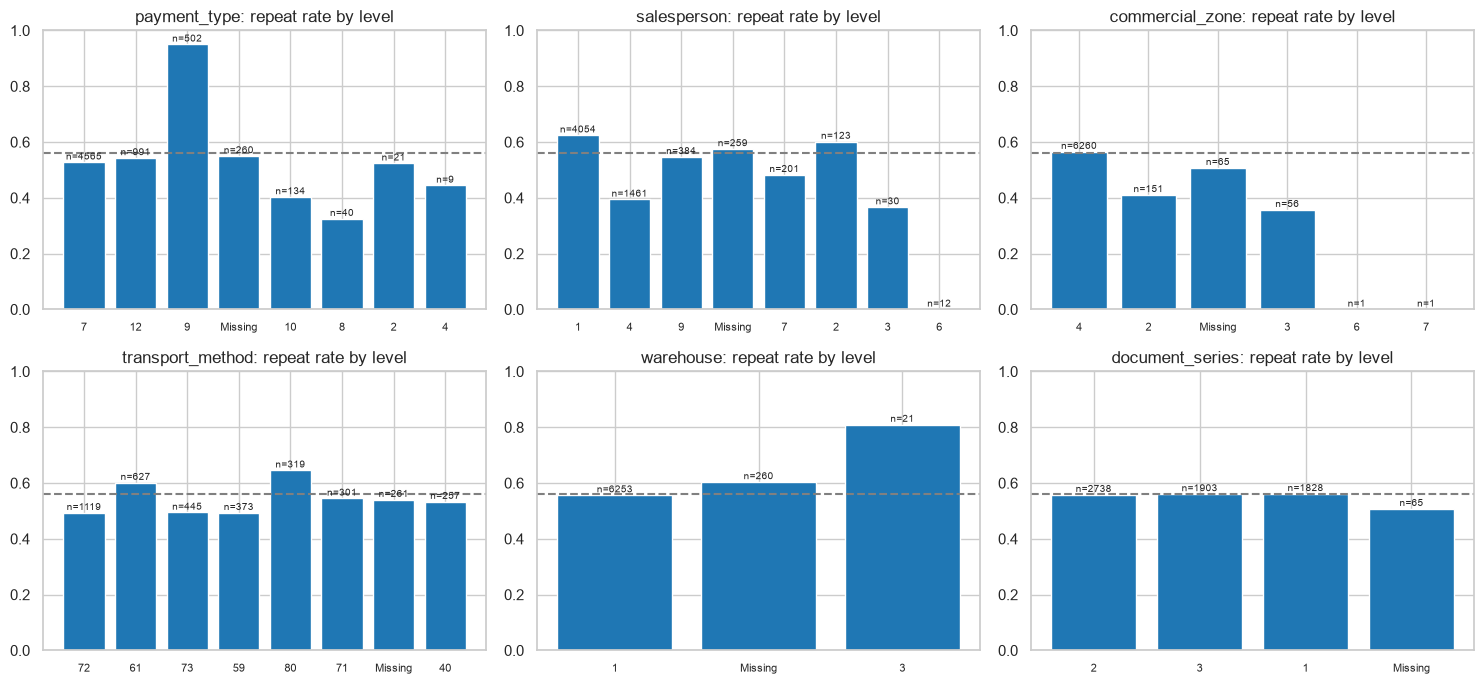

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), cat_cols_raw):
    top = train_raw[c].fillna("Missing").value_counts().head(8).index
    d = train_raw[train_raw[c].fillna("Missing").isin(top)].assign(**{c: lambda x: x[c].fillna("Missing")})
    g = d.groupby(c)[TARGET].agg(["mean", "size"]).sort_values("size", ascending=False)
    ax.bar(g.index.str.replace(r"^.* (\S+)$", r"\1", regex=True), g["mean"], color="tab:blue")
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, m + 0.01, f"n={n}", ha="center", fontsize=7)
    ax.axhline(train_raw[TARGET].mean(), ls="--", c="grey")
    ax.set_ylim(0, 1); ax.set_title(f"{c}: repeat rate by level"); ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.savefig(FIG / "categorical_target_rate.png", dpi=120); plt.show()

**Insights.**
- The labels are anonymised (e.g. `Maybe Tomorrow Payment 7`) but consistently formatted. They only need whitespace/case normalisation.
- Most categoricals are dominated by one level (`warehouse` 1 ≈ 97%, `commercial_zone` 4 ≈ 97%). Rare levels have very small counts, so their target rates are unreliable. We will group rare levels (`min_frequency` in the encoder).
- Some levels are strongly informative. `payment_type` 9 (n≈500) repeats about 95% of the time, which suggests a recurring/contract payment arrangement. `salesperson` 4 has a clearly lower repeat rate (about 0.39).
- `document_series` shows the **same** repeat rate (about 0.56) for every level, so dropping it costs no predictive information.
- **Train/test shift.**
  - `document_series` takes a *single* value in test (Series 2) but four in train. It cannot help rank test observations and may carry period-specific effects.
  - `commercial_zone` 1 and 5 (about 21% of test) never occur in train.
  - Some `payment_type` levels are new in test.

  The encoder must therefore handle unknown categories safely.

### 1.6 Time dimension

Train purchase dates: 2015-07-11 -> 2025-02-15
Test  purchase dates: 2025-05-24 -> 2026-10-06
Test customers already seen in train: 94.5% of test rows


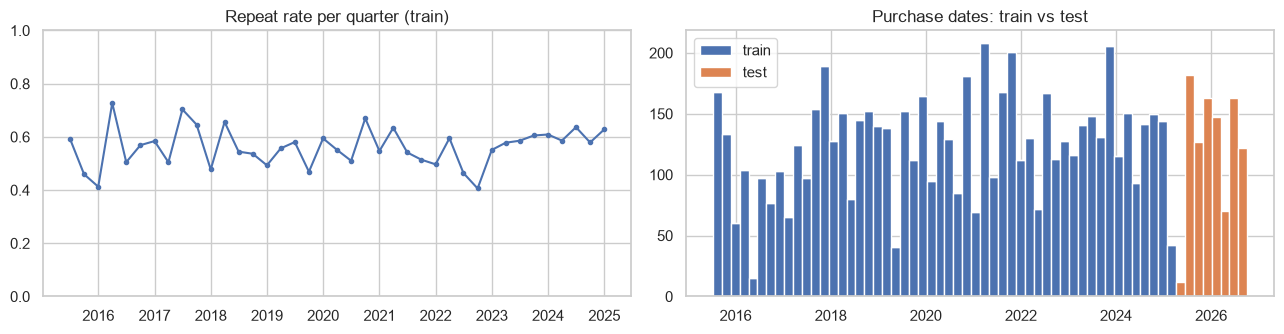

In [10]:
d_tr = pd.to_datetime(train_raw.purchase_date); d_te = pd.to_datetime(test_raw.purchase_date)
print(f"Train purchase dates: {d_tr.min().date()} -> {d_tr.max().date()}")
print(f"Test  purchase dates: {d_te.min().date()} -> {d_te.max().date()}")
print(f"Test customers already seen in train: {test_raw.customer_id.isin(train_raw.customer_id).mean():.1%} of test rows")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
by_q = train_raw.assign(q=d_tr.dt.to_period("Q").dt.start_time).groupby("q")[TARGET].agg(["mean", "size"])
axes[0].plot(by_q.index, by_q["mean"], marker="o", ms=3)
axes[0].set_title("Repeat rate per quarter (train)"); axes[0].set_ylim(0, 1)
axes[1].hist([d_tr.dropna(), d_te], bins=60, label=["train", "test"], stacked=True)
axes[1].legend(); axes[1].set_title("Purchase dates: train vs test")
plt.tight_layout(); plt.savefig(FIG / "time.png", dpi=120); plt.show()

**Insights (these drive the validation design).**
- The split is **temporal**. Train ends in Feb 2025 and test covers May 2025 to Oct 2026. The gap of about 3 months is consistent with the 90-day label horizon. One test purchase is dated **2026-10-06**, which is after the date of this analysis. We keep it (it must be predicted), but it is flagged as a data-quality issue.
- About 95% of test rows come from customers already present in train. The realistic question is "how well does a model trained on the past predict the *future*?", so validation must use **time-ordered splits**, not random K-fold.
- The repeat rate is fairly stable over time (about 0.5–0.63 per quarter), with no strong trend.

### 1.7 Numerical variables: distributions and relation to the target

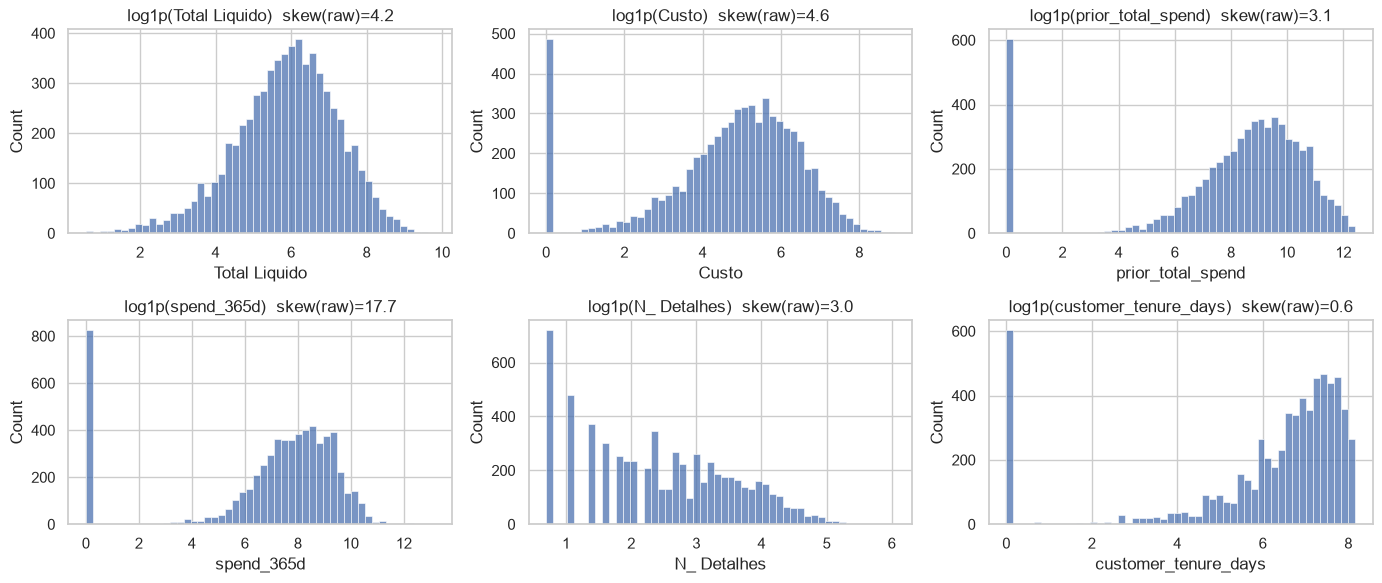

In [11]:
t = train_raw[~empty_rows].copy()
for c in ["prior_mean_purchase_value", "spend_365d"]:
    t.loc[t[c] >= 1e9, c] = np.nan
money = ["Total Liquido", "Custo", "prior_total_spend", "spend_365d", "N_ Detalhes", "customer_tenure_days"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, c in zip(axes.ravel(), money):
    sns.histplot(np.log1p(t[c].clip(lower=0)), bins=50, ax=ax)
    ax.set_title(f"log1p({c})  skew(raw)={t[c].skew():.1f}")
plt.tight_layout(); plt.show()

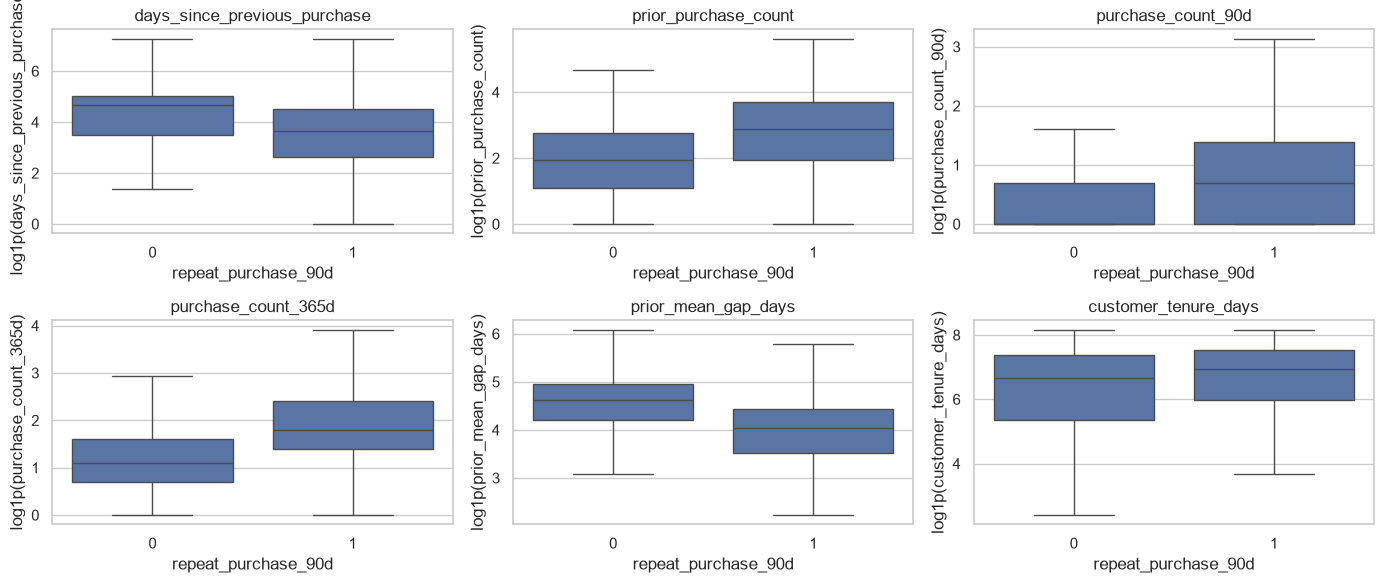

In [12]:
rfm = ["days_since_previous_purchase", "prior_purchase_count", "purchase_count_90d", "purchase_count_365d",
       "prior_mean_gap_days", "customer_tenure_days"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, c in zip(axes.ravel(), rfm):
    sns.boxplot(x=TARGET, y=np.log1p(t[c].clip(lower=0)), data=t, ax=ax, showfliers=False)
    ax.set_ylabel(f"log1p({c})"); ax.set_title(c)
plt.tight_layout(); plt.savefig(FIG / "rfm_boxplots.png", dpi=120); plt.show()

**Insights.**
- Monetary and count variables are **strongly right-skewed**, with a few very large customers. A `log1p` transform gives much more symmetric distributions. This matters for the linear model and for scaling.
- **Recency and frequency separate the classes clearly.** Repeat purchases come from customers who bought recently (low `days_since_previous_purchase`), buy often (high `purchase_count_90d/365d`, low `prior_mean_gap_days`) and have a longer history. This is the classic RFM (recency, frequency, monetary) pattern.

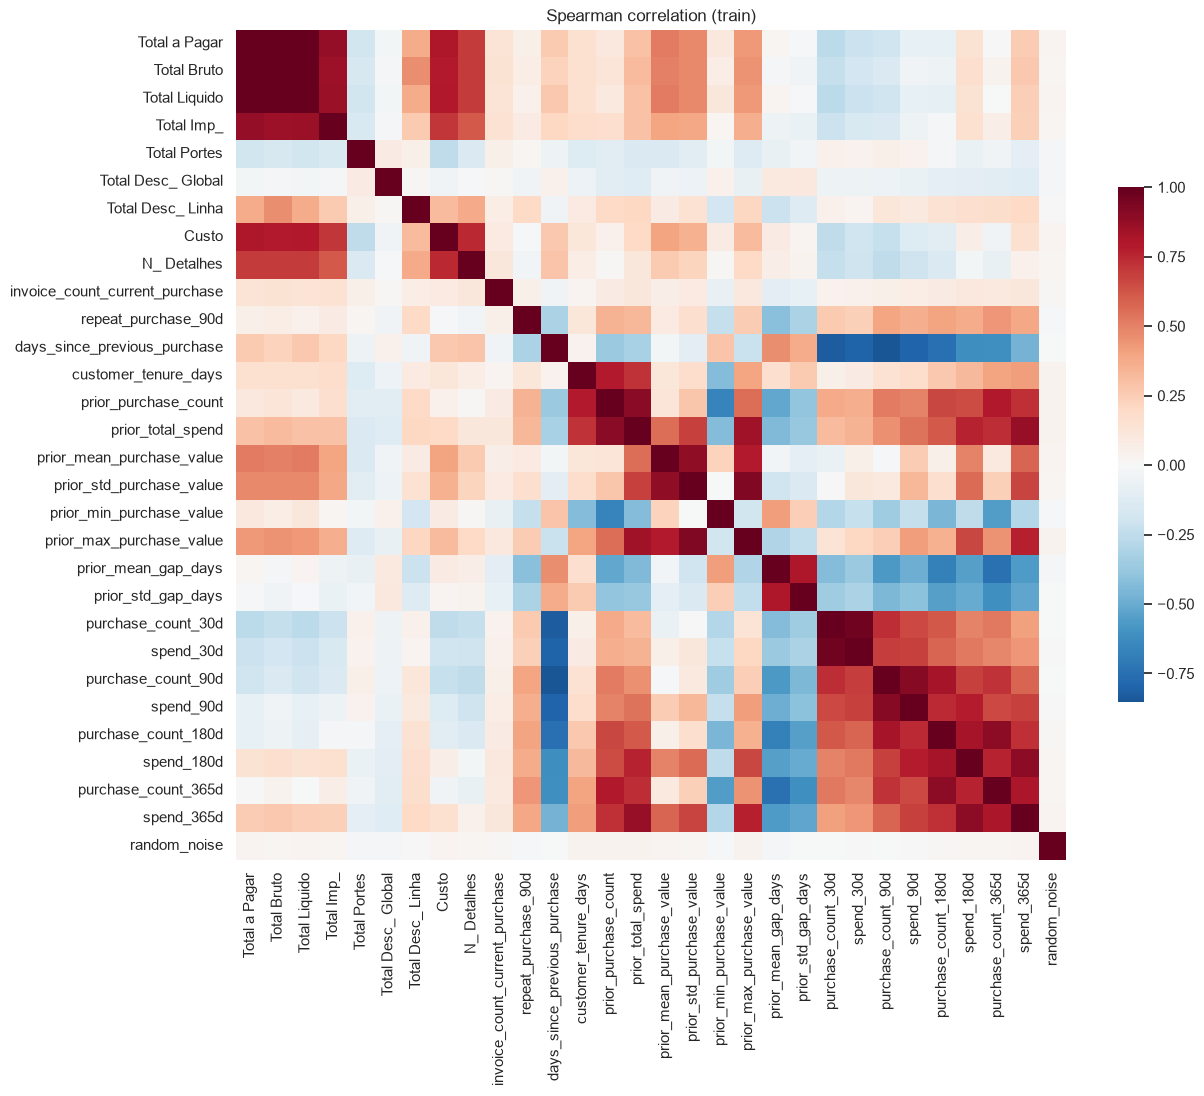

Spearman correlation with target (top 12 by |rho|):
purchase_count_365d             0.437
prior_mean_gap_days            -0.417
purchase_count_180d             0.406
purchase_count_90d              0.393
spend_365d                      0.387
spend_180d                      0.370
spend_90d                       0.359
prior_purchase_count            0.346
prior_total_spend               0.332
prior_std_gap_days             -0.315
days_since_previous_purchase   -0.311
purchase_count_30d              0.261
Name: repeat_purchase_90d, dtype: float64


In [13]:
num_cols_eda = t.select_dtypes("number").drop(columns=["ID", "customer_id"]).columns
corr = t[num_cols_eda].corr(method="spearman")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, square=True, cbar_kws={"shrink": .6}, xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation (train)"); plt.tight_layout(); plt.savefig(FIG / "correlation.png", dpi=110); plt.show()
print("Spearman correlation with target (top 12 by |rho|):")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).head(12).round(3))

**Insights (multivariate).**
- The invoice amounts (`Total a Pagar`, `Bruto`, `Liquido`, `Imp_`, `Custo`) are **almost perfectly collinear** (ρ > 0.9). They largely describe the same quantity, so the feature-selection step should keep only one or two of them.
- The rolling windows form nested blocks (30 ⊂ 90 ⊂ 180 ⊂ 365 days), so counts and spends of the same window are highly correlated.
- The strongest single associations with the target are the **frequency/recency** features. Current-order value is only weakly related.
- `random_noise` is uncorrelated with everything, as expected. It will serve as a reference: a useful feature must beat it.

### 1.8 Customer table `clientes.csv`

In [14]:
cl_info = pd.DataFrame({"n_missing": clients_raw.isna().sum(), "pct_missing": (clients_raw.isna().mean()*100).round(1),
                        "n_unique": clients_raw.nunique()})
print(f"customer_id unique in clientes: {clients_raw.customer_id.is_unique}; "
      f"train customers found: {train_raw.customer_id.isin(clients_raw.customer_id).mean():.0%}, "
      f"test customers found: {test_raw.customer_id.isin(clients_raw.customer_id).mean():.0%}")
print("Rows per customer in train:", train_raw.customer_id.value_counts().describe().round(1).to_dict())
cl_info

customer_id unique in clientes: True; train customers found: 100%, test customers found: 100%
Rows per customer in train: {'count': 610.0, 'mean': 10.7, 'std': 20.0, 'min': 1.0, '25%': 1.0, '50%': 4.0, '75%': 12.0, 'max': 277.0}


,n_missing,pct_missing,n_unique
customer_id,0,0.0,1143
country_or_region,0,0.0,11
commercial_region,114,10.0,37
island,578,50.6,10
municipality,159,13.9,183
city,546,47.8,417
postal_area,71,6.2,271
postal_code,170,14.9,828
street,598,52.3,511
address,6,0.5,1120


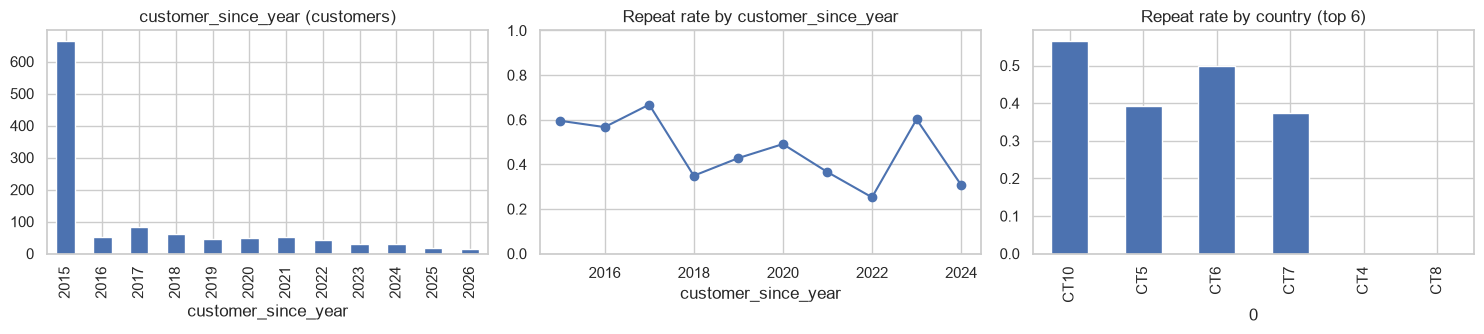

In [15]:
m = train_raw.merge(clients_raw, on="customer_id", how="left")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
clients_raw.customer_since_year.value_counts().sort_index().plot.bar(ax=axes[0], title="customer_since_year (customers)")
m.groupby("customer_since_year")[TARGET].mean().plot(ax=axes[1], marker="o", title="Repeat rate by customer_since_year"); axes[1].set_ylim(0, 1)
cr = m.country_or_region.str.extract(r"(CT\d+)")[0].fillna("NA")
m.groupby(cr)[TARGET].agg(["mean", "size"]).sort_values("size", ascending=False).head(6)["mean"].plot.bar(ax=axes[2], title="Repeat rate by country (top 6)")
plt.tight_layout(); plt.show()

**Insights.**
- Every `customer_id` in train and test is found in `clientes` (1 row per customer), so a left join is safe.
- `customer_type` is 100% empty, so it is dropped. `company_name` and `address` are unique per customer and `street`/`postal_code` are near-unique. These are **identifier-like**: they would let a model memorise individual customers and would not generalise, so they are dropped.
- The useful, low-cardinality information is: **`customer_since_year`** (relationship age), **`country_or_region`** (about 94% in one country), **`commercial_region`** (38 levels, rare ones to be grouped), and whether the address is on an **island** (a logistics proxy). `customer_since_year = 2015` covers 58% of customers, which looks like a system-start/censoring value ("2015 or earlier").
- Customer concentration is high: one customer has 277 train rows. Keeping `customer_id` as a feature would let the model memorise these heavy customers, so the history features (`prior_*`, windows) are the proper way to describe customers.

## 2. Clean and pre-process the data

The work is split into **two layers**:

1. **Stateless functions** (`clean`, `integrate_clients`, `add_features`). They use only the values of each row and fixed, documented rules. Nothing is learned from the data, so they can be applied to train and test in the same way without leakage.
2. **A fitted scikit-learn `Pipeline`** (imputation → transformation → scaling → encoding → model). It is fitted only on the training folds, so each validation fold and the test set are transformed with statistics learned from training data only.

### 2.1 Stateless cleaning

In [16]:
RENAME = {"Total a Pagar": "total_to_pay", "Total Bruto": "total_gross", "Total Liquido": "total_net",
          "Total Imp_": "total_tax", "Total Portes": "total_shipping", "Total Desc_ Global": "discount_global",
          "Total Desc_ Linha": "discount_line", "Custo": "cost", "N_ Detalhes": "n_lines"}
CAT_OPS = ["payment_type", "salesperson", "commercial_zone", "transport_method", "warehouse", "document_series"]
SENTINEL = 1e9
NON_NEGATIVE = ["days_since_previous_purchase", "prior_mean_purchase_value", "prior_mean_gap_days", "spend_365d",
                "prior_std_gap_days", "prior_std_purchase_value", "prior_min_purchase_value", "prior_max_purchase_value"]


def clean(df: pd.DataFrame) -> pd.DataFrame:
    # Row-wise, rule-based cleaning shared by train and test (no statistics are learned here).
    df = df.rename(columns=RENAME).copy()
    num = df.select_dtypes("number").columns.difference(["ID", "customer_id", TARGET, "random_noise"])
    audit = {}

    # 1) Sentinel codes (1e9) and impossible negatives -> missing
    audit["sentinel_1e9"] = int((df[num] >= SENTINEL).sum().sum())
    df[num] = df[num].mask(df[num] >= SENTINEL)
    neg = df[NON_NEGATIVE] < 0
    audit["negative_values"] = int(neg.sum().sum())
    df[NON_NEGATIVE] = df[NON_NEGATIVE].mask(neg)

    # 2) Logically inconsistent aggregates -> missing (rolling windows are nested and bounded by the total)
    bad365 = (df.spend_365d < df.spend_180d - 1e-6) | (df.spend_365d > df.prior_total_spend + 1e-6)
    badmax = df.prior_max_purchase_value > df.prior_total_spend + 1e-6
    audit["inconsistent_spend_365d"] = int(bad365.sum()); audit["inconsistent_prior_max"] = int(badmax.sum())
    df.loc[bad365, "spend_365d"] = np.nan
    df.loc[badmax, "prior_max_purchase_value"] = np.nan

    # 3) Deterministic reconstruction from accounting identities verified in the EDA
    has_prior = df.prior_purchase_count > 0
    mean_calc = df.prior_total_spend / df.prior_purchase_count.where(has_prior)
    fix_mean = has_prior & (df.prior_mean_purchase_value.isna() | ~np.isclose(df.prior_mean_purchase_value, mean_calc))
    df.loc[fix_mean, "prior_mean_purchase_value"] = mean_calc[fix_mean]
    one_prior = (df.prior_purchase_count == 1) & df.days_since_previous_purchase.isna()     # previous = first purchase
    df.loc[one_prior, "days_since_previous_purchase"] = df.loc[one_prior, "customer_tenure_days"]
    gap_calc = (df.customer_tenure_days - df.days_since_previous_purchase) / (df.prior_purchase_count - 1)
    fix_gap = (df.prior_purchase_count >= 2) & df.prior_mean_gap_days.isna() & gap_calc.notna()
    df.loc[fix_gap, "prior_mean_gap_days"] = gap_calc[fix_gap]
    audit.update(recomputed_prior_mean=int(fix_mean.sum()), recomputed_days_since_prev=int(one_prior.sum()),
                 recomputed_mean_gap=int(fix_gap.sum()))

    # 4) Categorical labels: normalise whitespace/case, keep 'Missing' as an explicit level
    for c in CAT_OPS:
        df[c] = df[c].astype("object").str.strip().str.replace(r"\s+", " ", regex=True).str.title()

    # 5) Types
    df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")
    for c in ["n_lines", "invoice_count_current_purchase", "prior_purchase_count"] + \
             [f"purchase_count_{w}d" for w in (30, 90, 180, 365)]:
        df[c] = df[c].astype("float64")
    df.attrs["audit"] = audit
    return df


# Drop the fully empty training rows (no information; a decision on *training observations* only)
train_nonempty = train_raw[~empty_rows].reset_index(drop=True)
train_c = clean(train_nonempty)
test_c = clean(test_raw)
print("Train cleaning audit:", train_c.attrs["audit"])
print("Test  cleaning audit:", test_c.attrs["audit"])
print(f"\nTrain rows: {len(train_raw)} -> {len(train_c)} (removed {empty_rows.sum()} empty rows); test rows kept: {len(test_c)}")

Train cleaning audit: {'sentinel_1e9': 31, 'negative_values': 63, 'inconsistent_spend_365d': 39, 'inconsistent_prior_max': 45, 'recomputed_prior_mean': 272, 'recomputed_days_since_prev': 22, 'recomputed_mean_gap': 203}
Test  cleaning audit: {'sentinel_1e9': 4, 'negative_values': 8, 'inconsistent_spend_365d': 7, 'inconsistent_prior_max': 6, 'recomputed_prior_mean': 41, 'recomputed_days_since_prev': 1, 'recomputed_mean_gap': 32}

Train rows: 6534 -> 6469 (removed 65 empty rows); test rows kept: 986


**Decisions and justification.**

| Issue | Handling | Why |
|---|---|---|
| 65 empty rows | Dropped (train only) | No features, so nothing to learn. Test rows are never dropped. |
| `1e9` codes, negative recency/spend | Set to `NaN` | Physically impossible values. They would dominate means, scaling and linear coefficients. |
| `spend_365d` outside `[spend_180d, prior_total]`, `prior_max > prior_total` | Set to `NaN` | These break logical constraints (nested windows, bounded by the total). |
| Missing/corrupted `prior_mean`, recency, mean gap | **Recomputed** from exact identities (`total/count`; tenure when only one prior purchase; `(tenure − recency)/(count − 1)`) | Uses only information in the same row, recovers true values, and is fully reproducible. |
| Category labels | Normalised text; `NaN` → `"Missing"` inside the pipeline | Joint missingness is informative (an extraction issue). |

Outliers that are *plausible* (very large but consistent customers or orders) are **kept**. They are real business cases, and the `log1p` transform limits their influence.

### 2.2 Integration of `clientes.csv`
We merge through `customer_id` (a many-to-one left join). We keep only the non-identifying, low-cardinality attributes.

In [17]:
def integrate_clients(df: pd.DataFrame, clients: pd.DataFrame) -> pd.DataFrame:
    # Left-join the selected customer attributes (stateless: fixed column choice and parsing rules).
    c = clients[["customer_id", "country_or_region", "commercial_region", "island", "customer_since_year"]].copy()
    c["country"] = c.country_or_region.str.extract(r"(CT\d+)", expand=False)
    c["commercial_region"] = c.commercial_region.str.extract(r"(RG\d+)", expand=False)
    c["is_island"] = c.island.notna().astype(float)
    c = c.drop(columns=["country_or_region", "island"])
    out = df.merge(c, on="customer_id", how="left", validate="many_to_one")
    assert len(out) == len(df) and (out["ID"].values == df["ID"].values).all()   # order and size preserved
    return out

train_m = integrate_clients(train_c, clients_raw)
test_m = integrate_clients(test_c, clients_raw)
print("Dropped from clientes: customer_type (100% empty), company_name/address/street/postal_code/postal_area/city/municipality "
      "(identifier-like or high-cardinality, heavily missing, redundant with region).")
train_m[["customer_id", "country", "commercial_region", "is_island", "customer_since_year"]].head()

Dropped from clientes: customer_type (100% empty), company_name/address/street/postal_code/postal_area/city/municipality (identifier-like or high-cardinality, heavily missing, redundant with region).


,customer_id,country,commercial_region,is_island,customer_since_year
0,660784,CT10,RG25,0.0,2024
1,189146,CT10,RG17,1.0,2015
2,103940,CT10,RG23,0.0,2017
3,512927,CT10,RG17,1.0,2018
4,122356,CT10,RG31,0.0,2017


### 2.3 Feature engineering

In [18]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    # Domain features built only from values in the same row.
    df = df.copy()
    safe = lambda s: s.where(s > 0)                       # avoid division by zero
    df["is_first_purchase"] = (df.prior_purchase_count == 0).astype(float)
    df["margin_rate"] = (df.total_net - df.cost) / safe(df.total_net)
    df["discount_rate"] = (df.discount_line + df.discount_global) / safe(df.total_gross)
    df["shipping_share"] = df.total_shipping / safe(df.total_to_pay)
    df["avg_line_value"] = df.total_net / safe(df.n_lines)
    df["recency_ratio"] = df.days_since_previous_purchase / safe(df.prior_mean_gap_days)   # >1: later than usual
    df["purchase_rate_365d"] = df.purchase_count_365d / np.minimum(df.customer_tenure_days, 365).clip(lower=1) * 30
    df["spend_trend_90_365"] = df.spend_90d / safe(df.spend_365d)
    df["count_trend_90_365"] = df.purchase_count_90d / safe(df.purchase_count_365d)
    df["order_vs_mean_value"] = df.total_net / safe(df.prior_mean_purchase_value)
    df["purchase_month"] = df.purchase_date.dt.month.astype(float)
    df["purchase_dow"] = df.purchase_date.dt.dayofweek.astype(float)
    age = df.purchase_date.dt.year - df.customer_since_year
    df["client_age_years"] = age.where(age >= 0)          # a 'since' year after the purchase is inconsistent -> NaN
    return df

train_f = add_features(train_m)
test_f = add_features(test_m)
print("Inconsistent customer_since_year (after the purchase year):", (train_m.purchase_date.dt.year < train_m.customer_since_year).sum())
new_feats = ["is_first_purchase", "margin_rate", "discount_rate", "shipping_share", "avg_line_value", "recency_ratio",
             "purchase_rate_365d", "spend_trend_90_365", "count_trend_90_365", "order_vs_mean_value",
             "purchase_month", "purchase_dow", "client_age_years"]
train_f[new_feats + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_frame("spearman_with_target")

Inconsistent customer_since_year (after the purchase year): 0


,spearman_with_target
purchase_rate_365d,0.426
discount_rate,0.218
spend_trend_90_365,0.189
count_trend_90_365,0.177
is_first_purchase,-0.146
margin_rate,0.118
client_age_years,0.108
purchase_dow,-0.094
avg_line_value,0.093
recency_ratio,-0.056


**Rationale.**
- **Recency relative to the customer's own rhythm** (`recency_ratio`) and **purchase rate** normalise raw recency and frequency by each customer's habits.
- **Trends** (`spend_trend_90_365`, `count_trend_90_365`) capture whether a customer is accelerating or churning.
- **Order profile**: margin, discount rate, shipping share, value per line, and order value vs the customer's usual order.
- **Seasonality**: month and day of week.
- **Relationship age**, from `clientes`.

All ratios guard against division by zero, and undefined ratios stay `NaN` for the fitted imputer.

### 2.4 Preprocessing pipeline (fitted on training data only)

| Column type | Steps | Why |
|---|---|---|
| Skewed non-negative (money, counts, days) | `log1p` → median imputation + missing indicator → `StandardScaler` | Log reduces skew and outlier leverage. The median is robust. The indicator keeps the information "value was missing". Scaling puts coefficients on a common scale for L1/L2 logistic regression. |
| Other numeric (ratios, flags, month) | median imputation + indicator → `StandardScaler` | Same idea, without log (some ratios can be negative). |
| Categorical | constant `"Missing"` → `OneHotEncoder(min_frequency=20, handle_unknown="infrequent_if_exist")` | Levels with fewer than 20 occurrences are pooled into "infrequent". Test-only levels (e.g. zones 1/5, new payment types) map to the infrequent bucket instead of crashing or creating spurious columns. |

Tree-based models do not need scaling. We keep the same pipeline for all models so they are compared fairly (scaling is harmless for trees).

In [19]:
NON_NEG_SKEWED = ["total_to_pay", "total_gross", "total_net", "total_tax", "total_shipping", "discount_global",
                  "discount_line", "cost", "n_lines", "invoice_count_current_purchase", "days_since_previous_purchase",
                  "customer_tenure_days", "prior_purchase_count", "prior_total_spend", "prior_mean_purchase_value",
                  "prior_std_purchase_value", "prior_min_purchase_value", "prior_max_purchase_value", "prior_mean_gap_days",
                  "prior_std_gap_days"] + [f"{k}_{w}d" for w in (30, 90, 180, 365) for k in ("purchase_count", "spend")] + \
                 ["avg_line_value", "recency_ratio", "purchase_rate_365d", "order_vs_mean_value"]
CATEGORICAL = CAT_OPS + ["country", "commercial_region"]


def make_preprocessor(features):
    # Build a ColumnTransformer for a given list of raw feature names.
    skewed = [f for f in features if f in NON_NEG_SKEWED]
    cats = [f for f in features if f in CATEGORICAL]
    other = [f for f in features if f not in skewed and f not in cats]
    log_num = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                        ("scale", StandardScaler())])
    num = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
                    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=False))])
    transformers = [(n, p, cols) for n, p, cols in [("log_num", log_num, skewed), ("num", num, other), ("cat", cat, cats)] if cols]
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

### 2.5 Validation design: time-ordered hold-out and time-series cross-validation

The test period lies *after* the training period, so we reproduce that setup inside `train`:

* **Hold-out**: the most recent 20% of training purchases (by date). It is used **once**, at the end, to estimate performance on unseen future data.
* **Development set**: all purchases at least **90 days before** the hold-out starts. This 90-day *embargo* is needed because a development label (repeat within 90 days) looks into the future. Without the gap, those labels would overlap the hold-out period.
* **Time-series CV on the development set**: 5 expanding-window folds. Each fold trains on the past (minus a 90-day embargo) and validates on the next time block. It is used for feature selection and hyper-parameter tuning.

Rows from the same customer can appear in training and validation folds. This is intended, because the same happens between train and test (about 95% of test customers are known).

In [20]:
def time_folds(dates: pd.Series, n_splits=5, gap_days=90):
    # Expanding-window folds on dates (positional indices), with an embargo of `gap_days` before each validation block.
    dates = pd.Series(pd.to_datetime(dates.values))
    edges = dates.quantile(np.linspace(0, 1, n_splits + 2)).values
    folds = []
    for k in range(1, n_splits + 1):
        start, end = edges[k], edges[k + 1]
        tr = np.where(dates < start - pd.Timedelta(days=gap_days))[0]
        va = np.where((dates >= start) & ((dates < end) if k < n_splits else (dates <= end)))[0]
        folds.append((tr, va))
    return folds

holdout_start = train_f.purchase_date.quantile(0.80)
is_holdout = train_f.purchase_date >= holdout_start
is_dev = train_f.purchase_date < holdout_start - pd.Timedelta(days=90)
dev = train_f[is_dev].sort_values("purchase_date").reset_index(drop=True)
hold = train_f[is_holdout].sort_values("purchase_date").reset_index(drop=True)
cv = time_folds(dev.purchase_date)

print(f"Hold-out starts {holdout_start.date()}: dev={len(dev)} rows, embargo={(~is_dev & ~is_holdout).sum()} rows, hold-out={len(hold)} rows")
print(f"Target rate dev={dev[TARGET].mean():.3f}, hold-out={hold[TARGET].mean():.3f}")
for i, (a, b) in enumerate(cv, 1):
    print(f"  fold {i}: train {len(a):5d} rows (..{dev.purchase_date.iloc[a].max().date()}) | "
          f"valid {len(b):4d} rows ({dev.purchase_date.iloc[b].min().date()} -> {dev.purchase_date.iloc[b].max().date()})")

Hold-out starts 2023-06-17: dev=5024 rows, embargo=147 rows, hold-out=1298 rows
Target rate dev=0.550, hold-out=0.603
  fold 1: train   750 rows (..2016-12-25) | valid  838 rows (2017-03-26 -> 2018-05-09)
  fold 2: train  1511 rows (..2018-02-16) | valid  830 rows (2018-05-19 -> 2019-08-23)
  fold 3: train  2347 rows (..2019-05-25) | valid  836 rows (2019-08-24 -> 2020-11-13)
  fold 4: train  3185 rows (..2020-08-02) | valid  844 rows (2020-11-14 -> 2021-11-29)
  fold 5: train  3936 rows (..2021-08-31) | valid  840 rows (2021-11-30 -> 2023-03-18)


## 3. Feature selection

Strategy (all computed on the **development set** / its CV folds only):

1. **Critical review of identifier-like and unusable variables** (domain rules).
2. **Filter methods**: near-constant variables, then redundancy removal among highly correlated pairs (|Spearman ρ| > 0.90), keeping the member with higher mutual information with the target.
3. **Embedded methods**:
   * **L1-regularised logistic regression (Lasso)**, which drops features whose coefficients shrink to zero;
   * **permutation importance** of a gradient-boosting model on the time-ordered validation folds, benchmarked against `random_noise`.
4. **Wrapper-style confirmation**: compare time-series CV ROC-AUC of the candidate feature sets (and with vs without `clientes` features) and pick the final set.

### 3.1 Critical review of identifier-like variables

In [21]:
ID_LIKE = {
    "ID": "row identifier, arbitrary ordering",
    "customer_id": "identifier; numeric value has no meaning; would memorise heavy customers (up to 277 rows)",
    "purchase_date": "raw timestamp does not extrapolate to the future test period (kept only via month/day-of-week)",
    "customer_since_year": "replaced by client_age_years (relative, time-invariant meaning)",
    "document_series": "single value in test (Series 2) vs 4 in train: no ranking power on test, period-specific",
}
print(pd.Series(ID_LIKE, name="reason for exclusion").to_frame().to_string())
all_candidates = [c for c in train_f.columns if c not in list(ID_LIKE) + [TARGET]]
print(f"\nCandidate features (incl. random_noise as a benchmark): {len(all_candidates)}")

                                                                                               reason for exclusion
ID                                                                               row identifier, arbitrary ordering
customer_id               identifier; numeric value has no meaning; would memorise heavy customers (up to 277 rows)
purchase_date        raw timestamp does not extrapolate to the future test period (kept only via month/day-of-week)
customer_since_year                                 replaced by client_age_years (relative, time-invariant meaning)
document_series            single value in test (Series 2) vs 4 in train: no ranking power on test, period-specific

Candidate features (incl. random_noise as a benchmark): 50


`random_noise` stays in the candidate set **only as a benchmark**. A feature whose importance is not above that of pure noise is not trusted. `random_noise` itself is removed from the final set.

### 3.2 Filter methods: near-constant and redundant features

In [22]:
dom_share = {c: dev[c].value_counts(normalize=True, dropna=False).iloc[0] for c in all_candidates}
near_constant = [c for c, s in dom_share.items() if s > 0.97]
print("Near-constant (one value > 97% of rows):", {c: round(dom_share[c], 3) for c in near_constant})
cand = [c for c in all_candidates if c not in near_constant]

num_cand = [c for c in cand if c not in CATEGORICAL]
X_mi = dev[num_cand].apply(lambda s: s.fillna(s.median()))
mi = pd.Series(mutual_info_classif(X_mi, dev[TARGET], random_state=RANDOM_STATE), index=num_cand).sort_values(ascending=False)

rho = dev[num_cand].corr(method="spearman").abs()
redundant = {}
for a in mi.index:                        # walk from most to least informative: drop weaker partners
    if a in redundant: continue
    for b in num_cand:
        if b != a and b not in redundant and mi[b] <= mi[a] and rho.loc[a, b] > 0.90:
            redundant[b] = f"rho={rho.loc[a, b]:.2f} with {a}"
print(f"\nRedundant (|rho|>0.90, lower MI dropped): {len(redundant)}")
print(pd.Series(redundant, name="kept partner").to_frame().to_string())
filtered = [c for c in cand if c not in redundant]
print(f"\nAfter filter step: {len(filtered)} features")

Near-constant (one value > 97% of rows): {'discount_global': np.float64(0.986), 'commercial_zone': np.float64(0.976), 'country': np.float64(0.975)}

Redundant (|rho|>0.90, lower MI dropped): 10
                                                    kept partner
prior_std_purchase_value  rho=0.94 with prior_max_purchase_value
spend_90d                       rho=0.92 with purchase_count_90d
spend_180d                              rho=0.90 with spend_365d
spend_trend_90_365              rho=0.94 with count_trend_90_365
prior_total_spend             rho=0.91 with prior_purchase_count
spend_30d                       rho=0.96 with purchase_count_30d
discount_line                        rho=0.90 with discount_rate
total_to_pay                           rho=0.99 with total_gross
total_net                              rho=0.99 with total_gross
shipping_share                      rho=0.99 with total_shipping

After filter step: 37 features


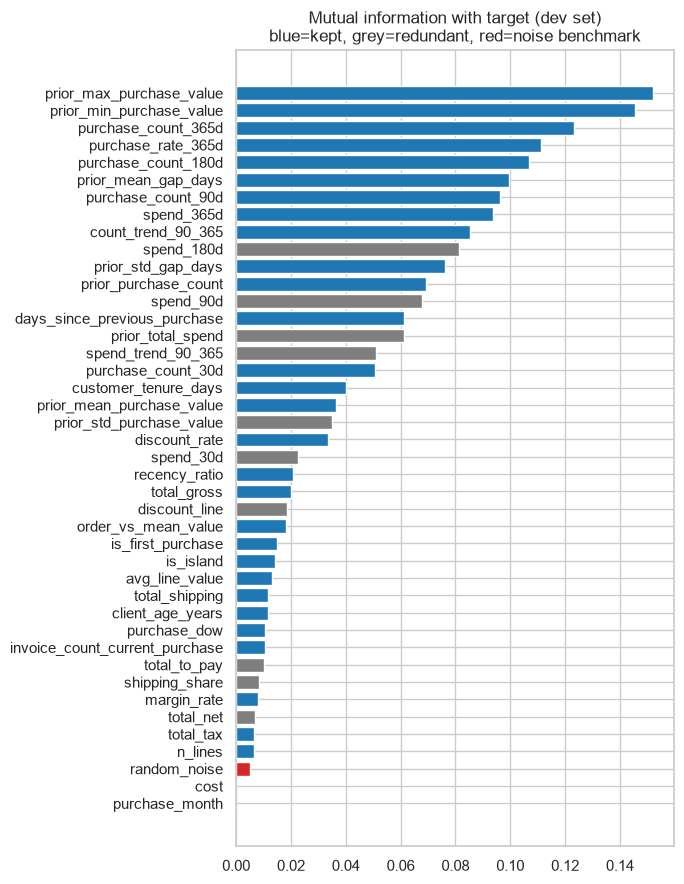

In [23]:
fig, ax = plt.subplots(figsize=(7, 9))
col = ["tab:red" if c == "random_noise" else ("tab:grey" if c in redundant else "tab:blue") for c in mi.index]
ax.barh(mi.index, mi.values, color=col); ax.invert_yaxis()
ax.set_title("Mutual information with target (dev set)\nblue=kept, grey=redundant, red=noise benchmark")
plt.tight_layout(); plt.savefig(FIG / "mutual_information.png", dpi=110); plt.show()

### 3.3 Embedded method 1 — L1-regularised logistic regression

In [24]:
def cv_auc(model, X, y, folds=cv):
    # Mean/std ROC-AUC over the time-series folds.
    s = [roc_auc_score(y.iloc[va], clone(model).fit(X.iloc[tr], y.iloc[tr]).predict_proba(X.iloc[va])[:, 1]) for tr, va in folds]
    return np.mean(s), np.std(s)

y_dev = dev[TARGET]
lasso_rows = []
for C in [0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 1.0]:
    pipe = Pipeline([("prep", make_preprocessor(filtered)),
                     ("clf", LogisticRegression(l1_ratio=1.0, C=C, solver="saga", max_iter=5000, random_state=RANDOM_STATE))])
    m, s = cv_auc(pipe, dev[filtered], y_dev)
    n_nz = (pipe.fit(dev[filtered], y_dev).named_steps["clf"].coef_ != 0).sum()
    lasso_rows.append({"C": C, "cv_auc": m, "cv_std": s, "non_zero_coefs": n_nz})
lasso_df = pd.DataFrame(lasso_rows); print(lasso_df.round(4).to_string(index=False))
# 1-standard-error rule: the most regularised model within 1 SE of the best CV AUC
best = lasso_df.cv_auc.idxmax()
C_l1 = lasso_df[lasso_df.cv_auc >= lasso_df.cv_auc[best] - lasso_df.cv_std[best] / np.sqrt(len(cv))].C.min()
print(f"\nChosen C (1-SE rule) = {C_l1}")

    C  cv_auc  cv_std  non_zero_coefs
0.005  0.7112  0.1077               5
0.010  0.7670  0.0218              12
0.020  0.7781  0.0173              13
0.050  0.7831  0.0154              20
0.100  0.7834  0.0149              32
0.300  0.7851  0.0169              61
1.000  0.7726  0.0175              85

Chosen C (1-SE rule) = 0.02


In [25]:
lasso = Pipeline([("prep", make_preprocessor(filtered)),
                  ("clf", LogisticRegression(l1_ratio=1.0, C=C_l1, solver="saga", max_iter=5000, random_state=RANDOM_STATE))]).fit(dev[filtered], y_dev)
coef = pd.Series(lasso.named_steps["clf"].coef_[0], index=lasso.named_steps["prep"].get_feature_names_out())

def original_feature(name):
    # Map an encoded column name back to its raw feature (one-hot levels and missing indicators).
    name = name.replace("missingindicator_", "")
    for f in sorted(filtered, key=len, reverse=True):
        if name == f or name.startswith(f + "_"):
            return f
    return name

l1_importance = coef.abs().groupby(coef.index.map(original_feature)).max().reindex(filtered).fillna(0)
l1_selected = l1_importance[l1_importance > 0].index.tolist()
print(f"L1 keeps {len(l1_selected)} of {len(filtered)} features; dropped: {sorted(set(filtered) - set(l1_selected))}")

L1 keeps 13 of 37 features; dropped: ['client_age_years', 'commercial_region', 'cost', 'count_trend_90_365', 'customer_tenure_days', 'days_since_previous_purchase', 'invoice_count_current_purchase', 'is_first_purchase', 'n_lines', 'order_vs_mean_value', 'payment_type', 'prior_mean_purchase_value', 'prior_min_purchase_value', 'prior_purchase_count', 'purchase_count_180d', 'purchase_count_30d', 'purchase_month', 'random_noise', 'recency_ratio', 'spend_365d', 'total_gross', 'total_shipping', 'transport_method', 'warehouse']


### 3.4 Embedded method 2 — permutation importance vs. the `random_noise` benchmark

random_noise importance: -0.0013
Permutation importance keeps 32 features above noise


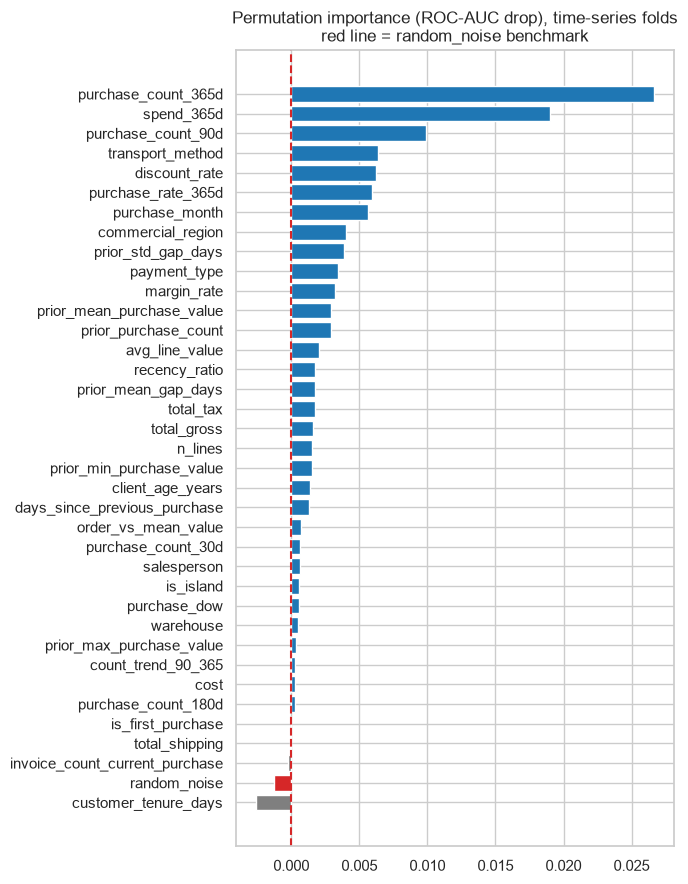

In [26]:
hgb_fs = Pipeline([("prep", make_preprocessor(filtered)),
                   ("clf", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300,
                                                          l2_regularization=1.0, random_state=RANDOM_STATE))])
imps = []
for tr, va in cv[-3:]:                     # the three most recent folds (largest training windows)
    fitted = clone(hgb_fs).fit(dev[filtered].iloc[tr], y_dev.iloc[tr])
    r = permutation_importance(fitted, dev[filtered].iloc[va], y_dev.iloc[va], scoring="roc_auc",
                               n_repeats=10, random_state=RANDOM_STATE)
    imps.append(pd.Series(r.importances_mean, index=filtered))
perm = pd.concat(imps, axis=1).mean(axis=1).sort_values(ascending=False)
noise_level = max(perm["random_noise"], 0)
perm_selected = perm[perm > noise_level].index.tolist()
print(f"random_noise importance: {perm['random_noise']:.4f}")
print(f"Permutation importance keeps {len(perm_selected)} features above noise")

fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(perm.index, perm.values, color=["tab:red" if c == "random_noise" else ("tab:blue" if c in perm_selected else "tab:grey") for c in perm.index])
ax.axvline(noise_level, color="tab:red", ls="--"); ax.invert_yaxis()
ax.set_title("Permutation importance (ROC-AUC drop), time-series folds\nred line = random_noise benchmark")
plt.tight_layout(); plt.savefig(FIG / "permutation_importance.png", dpi=110); plt.show()

### 3.5 Combine and confirm with time-series CV (wrapper-style check)

In [27]:
CLIENT_FEATS = {"country", "commercial_region", "is_island", "client_age_years"}
both = [f for f in filtered if f in l1_selected and f in perm_selected and f != "random_noise"]
either = [f for f in filtered if (f in l1_selected or f in perm_selected) and f != "random_noise"]
candidate_sets = {
    "A. all candidates (after ID review)": [c for c in all_candidates if c != "random_noise"],
    "B. filter step": [c for c in filtered if c != "random_noise"],
    "C. L1 ∪ permutation": either,
    "D. L1 ∩ permutation": both,
    "E. D without clientes features": [f for f in both if f not in CLIENT_FEATS],
}
lr_probe = LogisticRegression(C=0.1, max_iter=5000, random_state=RANDOM_STATE)
hgb_probe = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300, l2_regularization=1.0, random_state=RANDOM_STATE)
rows = []
for name, feats in candidate_sets.items():
    r = {"feature_set": name, "n_features": len(feats)}
    for mname, mdl in [("LogReg", lr_probe), ("HistGB", hgb_probe)]:
        m, s = cv_auc(Pipeline([("prep", make_preprocessor(feats)), ("clf", mdl)]), dev[feats], y_dev)
        r[f"{mname}_cv_auc"], r[f"{mname}_std"] = round(m, 4), round(s, 4)
    rows.append(r)
fs_table = pd.DataFrame(rows); fs_table

,feature_set,n_features,LogReg_cv_auc,LogReg_std,HistGB_cv_auc,HistGB_std
0,A. all candidates (after ID review),49,0.7827,0.0152,0.7722,0.0197
1,B. filter step,36,0.7830,0.0158,0.7753,0.0198
2,C. L1 ∪ permutation,32,0.7835,0.0156,0.7763,0.0187
3,D. L1 ∩ permutation,13,0.7866,0.0108,0.7593,0.0167
4,E. D without clientes features,12,0.7857,0.0135,0.7607,0.0145


In [28]:
# Selection rule: highest mean CV-AUC across the two model families; ties (<0.002) resolved in favour of the smaller set.
fs_table["mean_auc"] = fs_table[["LogReg_cv_auc", "HistGB_cv_auc"]].mean(axis=1)
top = fs_table.mean_auc.max()
chosen = fs_table[fs_table.mean_auc >= top - 0.002].sort_values("n_features").iloc[0]
SELECTED = candidate_sets[chosen.feature_set]
print(f"Chosen: {chosen.feature_set}  ({len(SELECTED)} features, mean CV AUC={chosen.mean_auc:.4f})")

just = pd.DataFrame({"feature": SELECTED,
                     "mutual_info": [round(mi.get(f, np.nan), 4) for f in SELECTED],
                     "L1_|coef|": [round(l1_importance.get(f, np.nan), 3) for f in SELECTED],
                     "perm_importance": [round(perm.get(f, np.nan), 4) for f in SELECTED],
                     "source": ["clientes" if f in CLIENT_FEATS else ("engineered" if f in new_feats else "train.csv") for f in SELECTED]})
just.sort_values("perm_importance", ascending=False).reset_index(drop=True)

Chosen: C. L1 ∪ permutation  (32 features, mean CV AUC=0.7799)


,feature,mutual_info,L1_|coef|,perm_importance,source
0,purchase_count_365d,0.1231,0.465,0.0267,train.csv
1,spend_365d,0.0937,0.000,0.0190,train.csv
2,purchase_count_90d,0.0963,0.414,0.0099,train.csv
3,transport_method,NaN,0.000,0.0064,train.csv
4,discount_rate,0.0337,0.137,0.0062,engineered
5,purchase_rate_365d,0.1113,0.077,0.0060,engineered
6,purchase_month,0.0000,0.000,0.0056,engineered
7,commercial_region,NaN,0.000,0.0040,clientes
8,prior_std_gap_days,0.0761,0.076,0.0039,train.csv
9,payment_type,NaN,0.000,0.0034,train.csv


**Final feature set — justification.**
- Every kept variable passed two tests:
  - it survived the filter step (not near-constant, not redundant with a stronger partner);
  - it was retained by the embedded method(s) that define the chosen set. The Lasso gives a non-zero weight to linear signals. Permutation importance, when a feature beats **pure noise** on *future* folds, also captures non-linear or categorical signals that the Lasso shrinks away.
- Among the candidate sets, the one with the best time-series CV ROC-AUC across both model families was chosen. Near-ties were resolved in favour of the smaller set.
- The kept variables cover the **RFM dimensions**: recency, frequency (purchase counts, purchase rate, gaps), monetary value (spend windows, prior spend), and the current-order profile (discount rate, margin, tax).
- Collinear invoice amounts were reduced to their most informative representative.
- Identifier-like variables (`ID`, `customer_id`, raw date, `document_series`) were excluded on principle, not because of a metric.
- **Customer table.** The with/without comparison (sets D vs E) shows how much `clientes` adds. We keep its features only if they survive the same objective criteria as the other variables.

## 4. Build a model and assess performance

**Metrics.**
- **ROC-AUC (primary).** It is threshold-independent and measures how well the model *ranks* likely repeaters above non-repeaters, which is what a retention/marketing team needs. It is also insensitive to the moderate 56/44 class balance.
- **PR-AUC.** It focuses on the quality of positive predictions.
- **Balanced accuracy / macro-F1 / F1 / accuracy.** These evaluate the final 0/1 predictions required by the submission file. Macro-F1 and balanced accuracy weight both classes equally, so the trivial "everyone repeats" rule is not rewarded.

**Models.** The majority-class `DummyClassifier` (baseline), **logistic regression** (simple, interpretable, the main "simple model"), plus a random forest and histogram gradient boosting for comparison. Hyper-parameters are tuned with `GridSearchCV` on the **time-series folds** of the development set.

In [29]:
X_dev, X_hold = dev[SELECTED], hold[SELECTED]
y_hold = hold[TARGET]

def pipe(model):
    return Pipeline([("prep", make_preprocessor(SELECTED)), ("clf", model)])

searches = {
    "Dummy (majority)": (pipe(DummyClassifier(strategy="prior")), {}),
    "Logistic regression": (pipe(LogisticRegression(max_iter=5000, solver="saga", random_state=RANDOM_STATE)),
                            {"clf__C": [0.01, 0.03, 0.1, 0.3, 1.0], "clf__l1_ratio": [0.0, 1.0],
                             "clf__class_weight": [None, "balanced"]}),
    "Random forest": (pipe(RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE)),
                      {"clf__max_depth": [6, 10, None], "clf__min_samples_leaf": [5, 20], "clf__max_features": ["sqrt", 0.3]}),
    "Hist. gradient boosting": (pipe(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
                                {"clf__learning_rate": [0.03, 0.08], "clf__max_depth": [3, 5], "clf__max_iter": [200, 400],
                                 "clf__l2_regularization": [0.0, 1.0]}),
}
fitted, cv_rows = {}, []
for name, (p, grid) in searches.items():
    gs = GridSearchCV(p, grid or {"clf__strategy": ["prior"]}, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True).fit(X_dev, y_dev)
    fitted[name] = gs
    i = gs.best_index_
    cv_rows.append({"model": name, "cv_roc_auc": gs.cv_results_["mean_test_score"][i], "cv_std": gs.cv_results_["std_test_score"][i],
                    "best_params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}})
cv_df = pd.DataFrame(cv_rows).round(4); cv_df

,model,cv_roc_auc,cv_std,best_params
0,Dummy (majority),0.5000,0.0000,{'strategy': 'prior'}
1,Logistic regression,0.7866,0.0149,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ..."
2,Random forest,0.7900,0.0100,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
3,Hist. gradient boosting,0.7854,0.0146,"{'l2_regularization': 1.0, 'learning_rate': 0...."


### 4.1 Decision threshold
The submission needs class labels. We choose the probability threshold that maximises **macro-F1** on the **out-of-fold predictions** of the development CV. We do not use the hold-out, so the hold-out estimate stays honest.

In [30]:
def oof_predictions(estimator, X, y, folds=cv):
    # Out-of-fold probabilities for the validation blocks of the time-series CV.
    idx, p = [], []
    for tr, va in folds:
        p.append(clone(estimator).fit(X.iloc[tr], y.iloc[tr]).predict_proba(X.iloc[va])[:, 1]); idx.append(va)
    idx = np.concatenate(idx)
    return y.iloc[idx].values, np.concatenate(p)

grid_t = np.round(np.arange(0.20, 0.81, 0.01), 2)
thresholds = {}
for name, gs in fitted.items():
    if name.startswith("Dummy"):
        thresholds[name] = 0.5; continue
    yt, pp = oof_predictions(gs.best_estimator_, X_dev, y_dev)
    scores = [f1_score(yt, pp >= t, average="macro") for t in grid_t]
    thresholds[name] = float(grid_t[int(np.argmax(scores))])
print("Chosen thresholds (max OOF macro-F1):", thresholds)

Chosen thresholds (max OOF macro-F1): {'Dummy (majority)': 0.5, 'Logistic regression': 0.52, 'Random forest': 0.57, 'Hist. gradient boosting': 0.56}


### 4.2 Hold-out evaluation (most recent 20% of training period, never used for any choice)

In [31]:
def evaluate(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {"roc_auc": roc_auc_score(y_true, proba) if len(np.unique(proba)) > 1 else 0.5,
            "pr_auc": average_precision_score(y_true, proba), "accuracy": accuracy_score(y_true, pred),
            "balanced_acc": balanced_accuracy_score(y_true, pred), "f1": f1_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"), "threshold": thr}

hold_rows, hold_proba = [], {}
for name, gs in fitted.items():
    hold_proba[name] = gs.best_estimator_.predict_proba(X_hold)[:, 1]
    hold_rows.append({"model": name, **evaluate(y_hold, hold_proba[name], thresholds[name])})
hold_df = pd.DataFrame(hold_rows).set_index("model").round(4)
hold_df.join(cv_df.set_index("model")[["cv_roc_auc", "cv_std"]])

,roc_auc,pr_auc,accuracy,balanced_acc,f1,macro_f1,threshold,cv_roc_auc,cv_std
model,,,,,,,,,
Dummy (majority),0.5000,0.6032,0.6032,0.5000,0.7525,0.3763,0.50,0.5000,0.0000
Logistic regression,0.7993,0.8656,0.7149,0.7116,0.7550,0.7071,0.52,0.7866,0.0149
Random forest,0.8158,0.8745,0.7273,0.7407,0.7493,0.7252,0.57,0.7900,0.0100
Hist. gradient boosting,0.8149,0.8751,0.7350,0.7401,0.7650,0.7306,0.56,0.7854,0.0146


Best CV model: Random forest (0.7900 ± SE 0.0045); logistic regression: 0.7866
==> Final model: Logistic regression


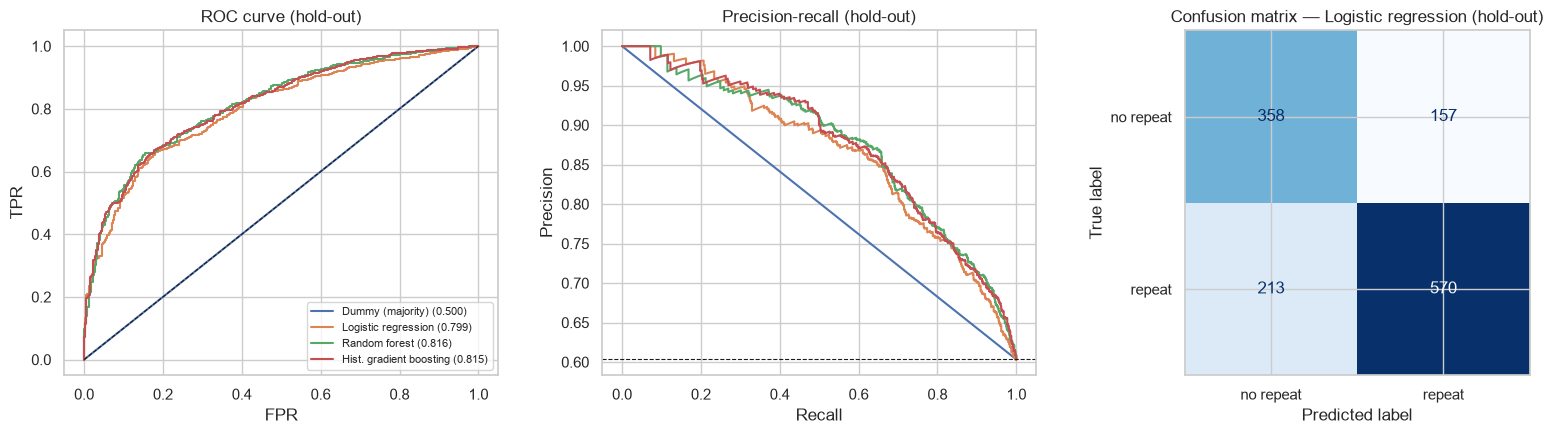

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for name, p in hold_proba.items():
    fpr, tpr, _ = roc_curve(y_hold, p); axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_hold, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_hold, p); axes[1].plot(rc, pr, label=name)
axes[0].plot([0, 1], [0, 1], "k--", lw=.8); axes[0].set(title="ROC curve (hold-out)", xlabel="FPR", ylabel="TPR"); axes[0].legend(fontsize=8)
axes[1].axhline(y_hold.mean(), color="k", ls="--", lw=.8); axes[1].set(title="Precision-recall (hold-out)", xlabel="Recall", ylabel="Precision")

non_dummy = hold_df.drop(index="Dummy (majority)")
best_by_cv = cv_df[cv_df.model != "Dummy (majority)"].sort_values("cv_roc_auc", ascending=False).iloc[0]
lr_row = cv_df[cv_df.model == "Logistic regression"].iloc[0]
# Model choice uses CV only (not the hold-out). Prefer the simpler logistic regression if within 1 SE of the best CV model.
se = best_by_cv.cv_std / np.sqrt(len(cv))
FINAL_NAME = "Logistic regression" if lr_row.cv_roc_auc >= best_by_cv.cv_roc_auc - se else best_by_cv.model
print(f"Best CV model: {best_by_cv.model} ({best_by_cv.cv_roc_auc:.4f} ± SE {se:.4f}); logistic regression: {lr_row.cv_roc_auc:.4f}")
print(f"==> Final model: {FINAL_NAME}")
ConfusionMatrixDisplay(confusion_matrix(y_hold, hold_proba[FINAL_NAME] >= thresholds[FINAL_NAME]),
                       display_labels=["no repeat", "repeat"]).plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title(f"Confusion matrix — {FINAL_NAME} (hold-out)")
plt.tight_layout(); plt.savefig(FIG / "holdout_evaluation.png", dpi=120); plt.show()

**Model choice.** The final model is picked from the **time-series CV** results only; the hold-out is used purely to confirm. If logistic regression is within one standard error of the best model, we prefer it: it is simpler, more stable over time, and its coefficients can be interpreted.

### 4.3 Interpretation of the final model

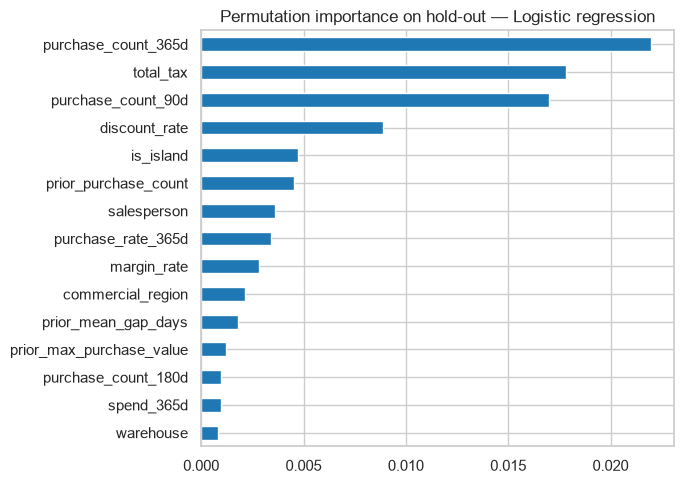

Solver converged: True (47 of 5000 iterations)
Largest standardised coefficients (positive = more likely to repeat):
purchase_count_365d                            0.361
purchase_count_90d                             0.359
total_tax                                      0.220
purchase_rate_365d                             0.200
discount_rate                                  0.169
salesperson_Vlookup Master 4                  -0.166
prior_max_purchase_value                       0.161
prior_purchase_count                           0.147
salesperson_Vlookup Master 1                   0.147
prior_mean_gap_days                           -0.142
transport_method_Maybe Tomorrow Delivery 68   -0.131
transport_method_Maybe Tomorrow Delivery 61   -0.129


In [33]:
final_est = fitted[FINAL_NAME].best_estimator_
r = permutation_importance(final_est, X_hold, y_hold, scoring="roc_auc", n_repeats=15, random_state=RANDOM_STATE)
imp = pd.Series(r.importances_mean, index=SELECTED).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="tab:blue"); ax.set_title(f"Permutation importance on hold-out — {FINAL_NAME}")
plt.tight_layout(); plt.savefig(FIG / "final_importance.png", dpi=120); plt.show()
if FINAL_NAME == "Logistic regression":
    clf = final_est.named_steps["clf"]
    print(f"Solver converged: {clf.n_iter_[0] < clf.max_iter} ({clf.n_iter_[0]} of {clf.max_iter} iterations)")
    c = pd.Series(final_est.named_steps["clf"].coef_[0], index=final_est.named_steps["prep"].get_feature_names_out())
    print("Largest standardised coefficients (positive = more likely to repeat):")
    print(c.reindex(c.abs().sort_values(ascending=False).index).head(12).round(3).to_string())

### 4.4 Final fit on all training data and predictions for `test.csv`
The chosen pipeline, with its tuned hyper-parameters, is **refitted on the full cleaned training set** (development + embargo + hold-out), so the most recent behaviour is included. The test set passes only through the stateless functions and `.predict_proba`.

In [34]:
final_model = clone(final_est).fit(train_f[SELECTED], train_f[TARGET])
THRESHOLD = thresholds[FINAL_NAME]
test_proba = final_model.predict_proba(test_f[SELECTED])[:, 1]
submission = pd.DataFrame({"ID": test_f["ID"].values, TARGET: (test_proba >= THRESHOLD).astype(int)})

# Integrity checks against the sample submission
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub) == len(test_raw)
assert (submission["ID"].values == sample_sub["ID"].values).all(), "ID order must match sample_submission"
assert submission[TARGET].isin([0, 1]).all() and submission.notna().all().all()
submission.to_csv(OUT / "submission.csv", index=False)
print(f"Saved {OUT/'submission.csv'}: {len(submission)} rows, predicted repeat rate = {submission[TARGET].mean():.3f} "
      f"(train rate {train_f[TARGET].mean():.3f}); threshold = {THRESHOLD}")
submission.head()

Saved outputs/submission.csv: 986 rows, predicted repeat rate = 0.640 (train rate 0.560); threshold = 0.52


,ID,repeat_purchase_90d
0,10000006,1
1,10000008,1
2,10000010,0
3,10000020,0
4,10000025,0


In [35]:
# Persist key results (used by the 2-page PDF report)
results = {
    "n_train_raw": int(len(train_raw)), "n_train_clean": int(len(train_f)), "n_test": int(len(test_f)),
    "n_dev": int(len(dev)), "n_holdout": int(len(hold)), "holdout_start": str(holdout_start.date()),
    "audit_train": train_c.attrs["audit"], "near_constant": near_constant, "n_redundant": len(redundant),
    "n_candidates": len(all_candidates) - 1, "feature_set_table": fs_table.drop(columns="mean_auc").to_dict("records"),
    "chosen_set": chosen.feature_set, "selected_features": SELECTED, "C_l1": float(C_l1),
    "cv": cv_df.assign(best_params=cv_df.best_params.astype(str)).to_dict("records"),
    "holdout": hold_df.reset_index().to_dict("records"), "final_model": FINAL_NAME, "threshold": THRESHOLD,
    "final_params": str(fitted[FINAL_NAME].best_params_), "test_pred_rate": float(submission[TARGET].mean()),
    "top_features": imp.head(8).round(4).to_dict(),
}
(OUT / "results.json").write_text(json.dumps(results, indent=2, default=str))
print("Saved outputs/results.json")

Saved outputs/results.json


### 4.5 Conclusions and limitations
- **What drives repeat purchases.** Recent, frequent and regular customers are much more likely to buy again within 90 days. Recency relative to the customer's usual gap and recent purchase counts are the most useful signals. Current-order amounts matter little once history is known.
- **Honest assessment.** The metrics come from a *future* hold-out with a 90-day embargo. They reproduce the real train→test setting, so they are a realistic (if slightly pessimistic, due to the smaller training window) estimate of test performance.
- **Limitations.**
  - Test contains commercial zones and payment types never seen in training (mapped to an "infrequent" bucket).
  - `document_series` changes between periods.
  - One test date lies in the future.
  - Heavy customers contribute many correlated rows. A customer-grouped validation would estimate performance for *new* customers, but that is not the main use case here.
- **Possible extensions**: probability calibration, cost-sensitive thresholds aligned with marketing costs, and customer-level aggregation of predictions.